# CNN Light Mel-Spectrogram
This notebook downloads and processes only the light mel-spectrogram dataset.

## Colab Runtime Setup
Local imports work in Colab only if `common_utils.py` and `cnn_utils.py` are present in the remote runtime. If you use the VS Code Colab extension, make sure both files are synced, uploaded, mounted from Drive, or downloaded before imports run.

In [1]:
import sys
from pathlib import Path

UTILS_GITHUB_RAW_BASE_URL = "https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main/utils"
UTILITY_FILES = ("common_utils.py",)

candidate_dirs = [
    Path.cwd() / "utils",
    Path.cwd().parent / "utils",
    Path("/content/utils"),
    Path("/content/drive/MyDrive/STUDA/src/utils"),
]

utilities_dir = next(
    (directory for directory in candidate_dirs if all((directory / filename).exists() for filename in UTILITY_FILES)),
    None,
)

if utilities_dir is None and UTILS_GITHUB_RAW_BASE_URL:
    import urllib.request
    utilities_dir = Path("/content")
    for filename in UTILITY_FILES:
        urllib.request.urlretrieve(f"{UTILS_GITHUB_RAW_BASE_URL}/{filename}", utilities_dir / filename)
    model_dir = Path("/content/CNN")
    model_dir.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve("https://raw.githubusercontent.com/Nabuhodonozzor/uuv-detection/main/CNN/cnn_utils.py", model_dir / "cnn_utils.py")

if utilities_dir is None or not all((utilities_dir / filename).exists() for filename in UTILITY_FILES):
    raise FileNotFoundError(
        f"{UTILITY_FILES} were not found in the Colab runtime. "
        "Sync them with the VS Code Colab extension, upload them to /content, mount Drive, "
        "or set UTILS_GITHUB_RAW_BASE_URL before importing."
    )

sys.path.insert(0, str(utilities_dir))
model_dirs = [Path.cwd(), Path.cwd() / "CNN", Path.cwd().parent / "CNN", Path("/content/CNN"), Path("/content/drive/MyDrive/STUDA/src/CNN")]
model_dir = next((directory for directory in model_dirs if (directory / "cnn_utils.py").exists()), None)
if model_dir is None:
    raise FileNotFoundError("cnn_utils.py was not found.")
sys.path.insert(0, str(model_dir))
print(f"Using utility modules from: {utilities_dir}")


Using pipeline module: /content/spectrogram_pipeline.py


In [2]:
from IPython.display import display
from google.colab import files, userdata

from common_utils import evaluate_models_for_variants, extract_zip, plot_training_histories, prepare_dataset_variants, save_keras_artifacts, train_keras_models_for_variants, zip_artifacts
from cnn_utils import build_cnn_models_for_variants, get_cnn_callbacks


## Dataset Download

In [3]:
DATASET_KEY = "light"
DATASET_LABEL = "Mel-Spectrogram Light"
DATASET_SLUG = "pawedyrda/mel-spectrogram-light"
ARCHIVE_PATH = Path("/content/mel-spectrogram-light.zip")
DATA_PATH = Path("/content/mel-spectrogram-light")
EPOCHS = 50
BATCH_SIZE = 32


In [4]:
kaggle_token = "KGAT_13e99a89ce99374acab577737d175634"

kaggle_dir = Path("/root/.kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)
token_path = kaggle_dir / "access_token"
token_path.write_text(kaggle_token)
token_path.chmod(0o600)


In [5]:
!kaggle datasets download -d {DATASET_SLUG} -p /content --force
DATA_PATH = extract_zip(ARCHIVE_PATH, "/content")
print(f"Dataset extracted to: {DATA_PATH}")


Dataset URL: https://www.kaggle.com/datasets/pawedyrda/mel-spectrogram-light
License(s): unknown
100% 630M/630M [00:34<00:00, 19.3MB/s] 

Dataset extracted to: /content


## Prepare Normal, M, And W Variants

In [6]:
variants = prepare_dataset_variants(DATA_PATH)
print("Normal train shape:", variants.normal.train_data.shape)
print("M train shape:", variants.m.train_data.shape)
print("W train shape:", variants.w.train_data.shape)


Scanning spectrogram data in: /content
Found .npz files: 9674, skipped: 0
Loaded samples: 9674
X shape: (9674, 309, 64)
y shape: (9674, 17)
Scanning spectrogram data in: /content (UUV filter: M)
Found .npz files: 9674, skipped: 523
Loaded samples: 9151
X shape: (9151, 309, 64)
y shape: (9151, 17)
Scanning spectrogram data in: /content (UUV filter: W)
Found .npz files: 9674, skipped: 379
Loaded samples: 9295
X shape: (9295, 309, 64)
y shape: (9295, 17)
Normal train shape: (6191, 309, 64, 1)
M train shape: (5856, 309, 64, 1)
W train shape: (5948, 309, 64, 1)


## Multilabel CNNs

In [7]:
multilabel_models = build_cnn_models_for_variants(variants, model_type="multilabel")
multilabel_histories = train_keras_models_for_variants(
    multilabel_models,
    variants,
    model_type="multilabel",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callback_factory=get_cnn_callbacks,
)


Training multilabel model for variant: normal
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 32s 90ms/step - binary_accuracy: 0.9049 - loss: 0.2543 - pr_auc: 0.3003 - precision: 0.4032 - recall: 0.2250 - roc_auc: 0.7947 - val_binary_accuracy: 0.9169 - val_loss: 0.2596 - val_pr_auc: 0.2430 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.7739 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - binary_accuracy: 0.9222 - loss: 0.2041 - pr_auc: 0.4696 - precision: 0.5923 - recall: 0.2988 - roc_auc: 0.8726 - val_binary_accuracy: 0.9261 - val_loss: 0.2054 - val_pr_auc: 0.4836 - val_precision: 0.7654 - val_recall: 0.1596 - val_roc_auc: 0.8665 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - binary_accuracy: 0.9277 - loss: 0.1865 - pr_auc: 0.5312 - precision: 0.6374 - recall: 0.3655 - roc_auc: 0.9024 - val_binary_accuracy: 0.9270 - val_loss: 0.1991 - val_pr_auc: 0.5150 - val_precision: 0.5915 - val_recall: 0.3946 - val_roc_

## Binary UUV CNNs

In [8]:
binary_models = build_cnn_models_for_variants(variants, model_type="binary")
binary_histories = train_keras_models_for_variants(
    binary_models,
    variants,
    model_type="binary",
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callback_factory=get_cnn_callbacks,
)


Training binary model for variant: normal
Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - binary_accuracy: 0.9037 - loss: 0.3053 - pr_auc: 0.1943 - precision: 0.3898 - recall: 0.0395 - roc_auc: 0.6637 - val_binary_accuracy: 0.9160 - val_loss: 0.3369 - val_pr_auc: 0.2542 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.6873 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - binary_accuracy: 0.9065 - loss: 0.2654 - pr_auc: 0.3156 - precision: 0.5169 - recall: 0.1046 - roc_auc: 0.7718 - val_binary_accuracy: 0.9186 - val_loss: 0.2579 - val_pr_auc: 0.3147 - val_precision: 0.8333 - val_recall: 0.0385 - val_roc_auc: 0.7138 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - binary_accuracy: 0.9136 - loss: 0.2465 - pr_auc: 0.3876 - precision: 0.6364 - recall: 0.1921 - roc_auc: 0.8163 - val_binary_accuracy: 0.9283 - val_loss: 0.2859 - val_pr_auc: 0.4382 - val_precision: 0.6173 - val_recall: 0.3846 - val_roc_auc:

## Evaluation

In [9]:
multilabel_results = evaluate_models_for_variants(
    multilabel_models, variants, model_type="multilabel", dataset_label=DATASET_LABEL
)
display(multilabel_results)

binary_results = evaluate_models_for_variants(
    binary_models, variants, model_type="binary", dataset_label=DATASET_LABEL
)
display(binary_results)



--- Evaluation for: Multilabel normal Mel-Spectrogram Light ---

                   precision    recall  f1-score   support

ArtificialSignals       0.99      0.95      0.97       199
 BigPassengerShip       0.96      0.96      0.96        27
            Cargo       0.97      0.95      0.96        39
         FishBoat       0.94      0.96      0.95        48
        GreenCity       0.94      0.89      0.91       108
           KaiYan       0.96      0.96      0.96        28
          KaiYuan       0.93      0.91      0.92       273
        MotorBoat       1.00      0.86      0.92        21
              No7       0.92      0.77      0.84       124
       PoliceBoat       0.73      0.89      0.80        18
          QianDao       0.92      0.98      0.95       662
        SpeedBoat       0.96      0.91      0.93       858
          TheEarl       0.94      1.00      0.97        98
        TheKnight       0.80      1.00      0.89        49
              UUV       0.99      0.94      0.97

,Model,precision,recall,f1-score,support
0,Multilabel normal Mel-Spectrogram Light,0.994413,0.941799,0.967391,189.0
1,Multilabel M Mel-Spectrogram Light,1.000000,0.969231,0.984375,65.0
2,Multilabel W Mel-Spectrogram Light,0.969072,0.979167,0.974093,96.0



--- Evaluation for: Binary normal Mel-Spectrogram Light ---

              precision    recall  f1-score   support

      No UUV       0.99      1.00      1.00      1746
         UUV       0.99      0.95      0.97       189

    accuracy                           0.99      1935
   macro avg       0.99      0.97      0.98      1935
weighted avg       0.99      0.99      0.99      1935


--- Evaluation for: Binary M Mel-Spectrogram Light ---

              precision    recall  f1-score   support

      No UUV       1.00      1.00      1.00      1766
         UUV       0.98      0.98      0.98        65

    accuracy                           1.00      1831
   macro avg       0.99      0.99      0.99      1831
weighted avg       1.00      1.00      1.00      1831


--- Evaluation for: Binary W Mel-Spectrogram Light ---

              precision    recall  f1-score   support

      No UUV       1.00      1.00      1.00      1763
         UUV       1.00      0.97      0.98        96

    ac

,Model,precision,recall,f1-score,support
0,Binary normal Mel-Spectrogram Light,0.994444,0.947090,0.970190,189.0
1,Binary M Mel-Spectrogram Light,0.984615,0.984615,0.984615,65.0
2,Binary W Mel-Spectrogram Light,1.000000,0.968750,0.984127,96.0


## Training Curves

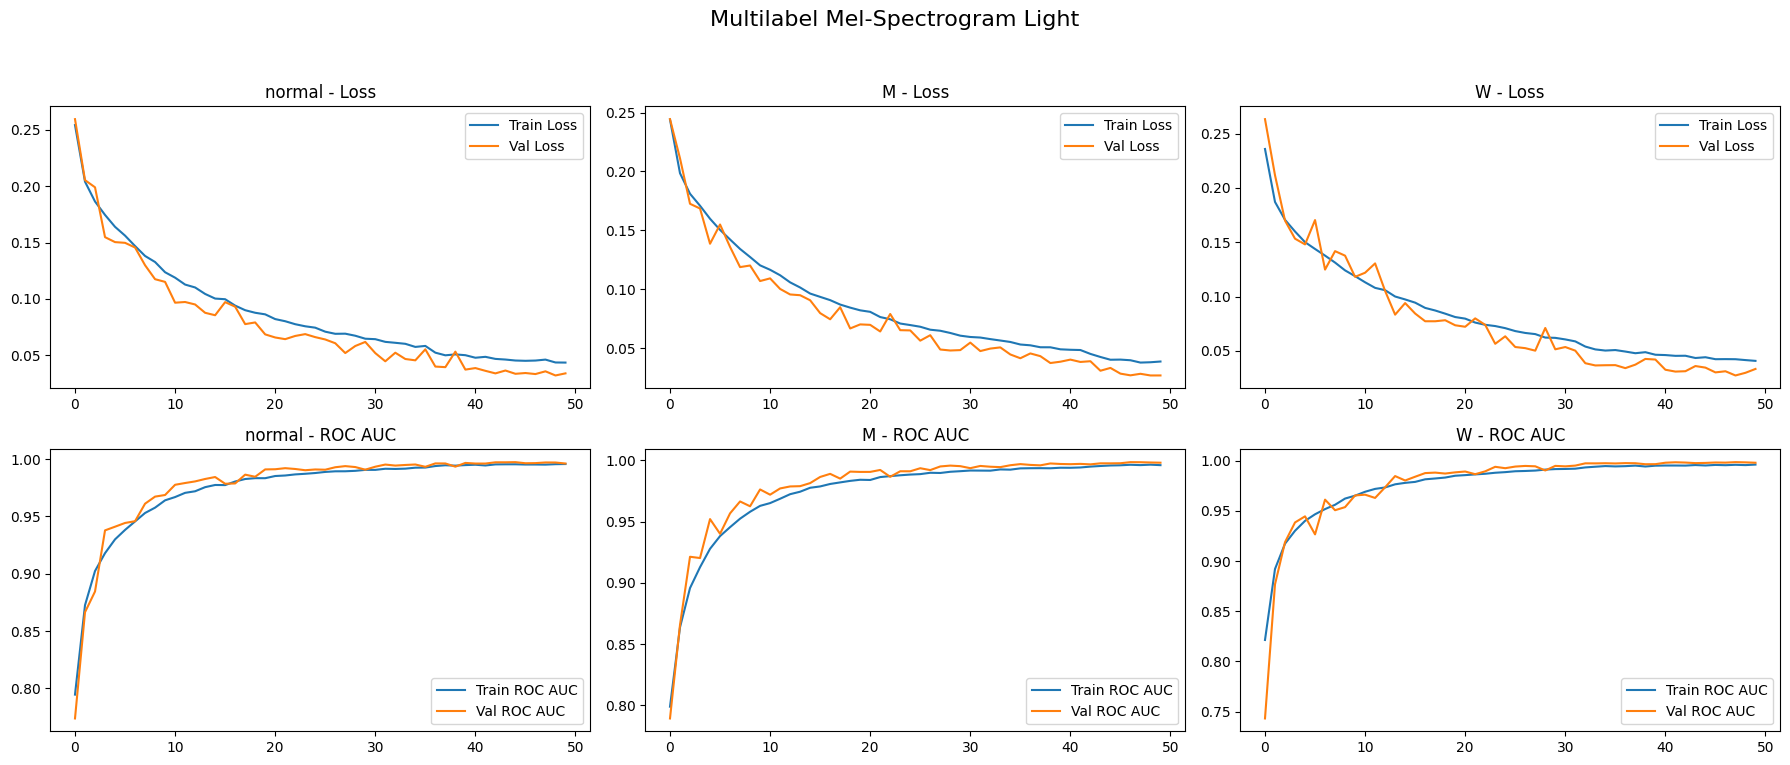

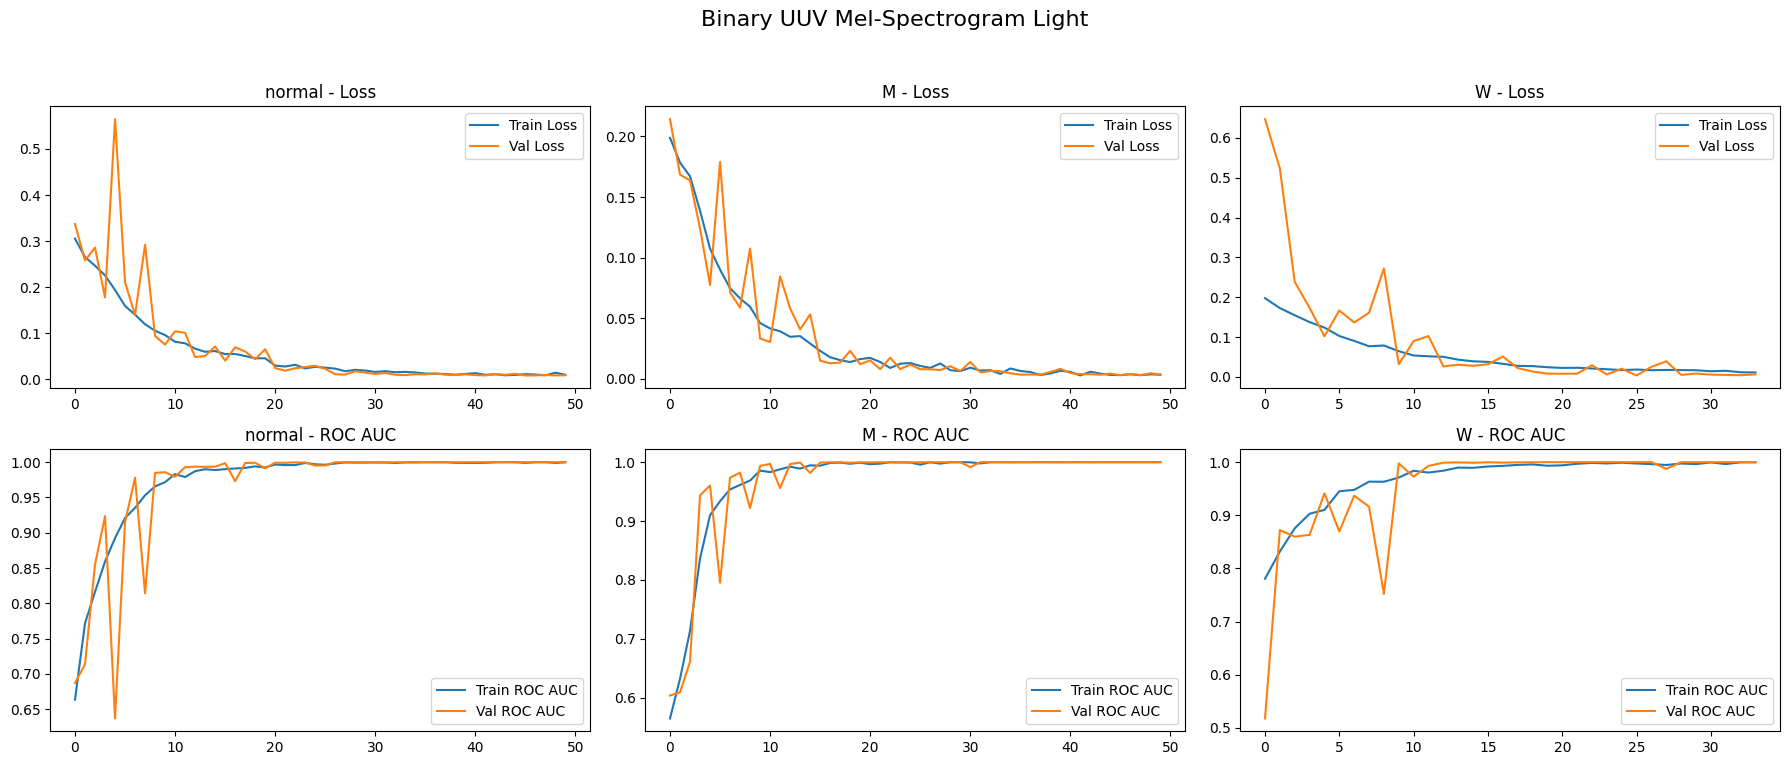

In [10]:
plot_training_histories(multilabel_histories, f"Multilabel {DATASET_LABEL}")
plot_training_histories(binary_histories, f"Binary UUV {DATASET_LABEL}")


## Save Artifacts

In [12]:
save_dir = save_keras_artifacts(
    save_dir="saved_artifacts",
    dataset_key=DATASET_KEY,
    multilabel_models=multilabel_models,
    binary_models=binary_models,
    multilabel_histories=multilabel_histories,
    binary_histories=binary_histories,
    multilabel_results=multilabel_results,
    binary_results=binary_results,
)
archive_path = zip_artifacts(save_dir, f"saved_models_and_results_{DATASET_KEY}.zip")
files.download(str(archive_path))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>